In [1]:
import deepchem as dc

from rdkit import Chem

import numpy as np

import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/.venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init_

## Import the dataset from deepchem and prepare cannonicallized SMILES

In [3]:
# Force re-download / re-featurize and save cache to a stable folder
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer="Raw",
    reload=True,
    data_dir="data",            # where raw data is stored
    save_dir="data/tox21-cache" # where featurized/cache files are written
)
train_dataset, valid_dataset, test_dataset = datasets

[14:02:56] WARNING: not removing hydrogen atom without neighbors
[14:02:56] Explicit valence for atom # 8 Al, 6, is greater than permitted
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:02:56] Explicit valence for atom # 3 Al, 6, is greater than permitted
Failed to featurize datapoint 2290, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:02:56] Explicit valence for atom # 4 Al, 6,

In [ ]:
# We only need the SMILES strings
train_smiles = train_dataset.X
valid_smiles = valid_dataset.X
test_smiles  = test_dataset.X

# Convert the RDKit molecules to cannonicallized SMILES strings
train_smiles = [Chem.MolToSmiles(mol) for mol in train_dataset.X]
valid_smiles = [Chem.MolToSmiles(mol) for mol in valid_dataset.X]
test_smiles  = [Chem.MolToSmiles(mol) for mol in test_dataset.X]

print(train_smiles[:5])

['CC(O)(P(=O)(O)O)P(=O)(O)O', 'CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C', 'OC[C@@H](O)[C@H](O)[C@@H](O)CO', 'CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]', 'CC(C)COC(=O)C(C)C']


### Filter out any strings above sequence length
We will use a sequence length of 120, just like the paper did. Even though we will have to remove some datapoints, this will make training much faster and a sequence length of 120 will cover over 90% of our datapoints


train: n=6258
  min=2  mean=31.3  median=25.0  max=277
  p 50=25
  p 75=37
  p 90=57
  p 95=73
  p 98=98
  p 99=130
  p100=277

valid: n=782
  min=9  mean=53.2  median=43.0  max=342
  p 50=43
  p 75=62
  p 90=88
  p 95=117
  p 98=174
  p 99=205
  p100=342

test: n=783
  min=5  mean=52.8  median=43.0  max=332
  p 50=43
  p 75=59
  p 90=90
  p 95=121
  p 98=196
  p 99=237
  p100=332


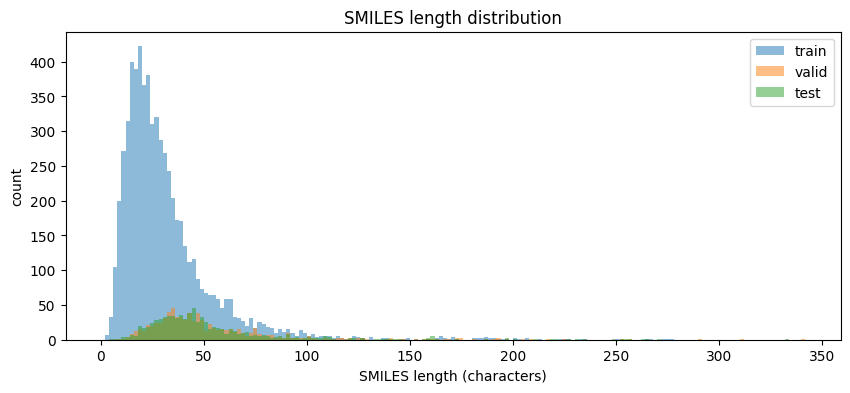

In [203]:
def summarize_lengths(name, smiles_list, percentiles=(50, 75, 90, 95, 98, 99, 100)):
    lens = np.array([len(s) for s in smiles_list], dtype=int)
    print(f"\n{name}: n={len(lens)}")
    print(f"  min={lens.min()}  mean={lens.mean():.1f}  median={np.median(lens):.1f}  max={lens.max()}")
    for p in percentiles:
        print(f"  p{p:>3}={np.percentile(lens, p):.0f}")
    return lens

train_lens = summarize_lengths("train", train_smiles)
valid_lens = summarize_lengths("valid", valid_smiles)
test_lens  = summarize_lengths("test",  test_smiles)

# Histogram (same bins for all)
max_len = max(train_lens.max(), valid_lens.max(), test_lens.max())
bins = np.arange(0, max_len + 2, 2)  # bin width=2 chars (adjust if you want)

plt.figure(figsize=(10, 4))
plt.hist(train_lens, bins=bins, alpha=0.5, label="train")
plt.hist(valid_lens, bins=bins, alpha=0.5, label="valid")
plt.hist(test_lens,  bins=bins, alpha=0.5, label="test")
plt.xlabel("SMILES length (characters)")
plt.ylabel("count")
plt.title("SMILES length distribution")
plt.legend()
plt.show()

In [204]:
#MAX_LEN = 120
MAX_LEN = 60

def filter_by_len(smiles_list, max_len=MAX_LEN):
    return [s for s in smiles_list if len(s) <= max_len]

def report_filter(name, smiles_list, max_len=MAX_LEN):
    n0 = len(smiles_list)
    kept = filter_by_len(smiles_list, max_len)
    n1 = len(kept)
    pct = 100.0 * n1 / n0 if n0 else 0.0
    print(f"{name}: kept {n1}/{n0} ({pct:.2f}%) with len <= {max_len}")
    return kept

train_smiles = report_filter("train", train_smiles, MAX_LEN)
valid_smiles = report_filter("valid", valid_smiles, MAX_LEN)
test_smiles  = report_filter("test",  test_smiles,  MAX_LEN)

train: kept 5721/6258 (91.42%) with len <= 60
valid: kept 577/782 (73.79%) with len <= 60
test: kept 597/783 (76.25%) with len <= 60


## Now we need to tokenize and Encode each SMILES string
In the paper, SMILES strings were tokenized using one-hot encodings, we will do the same

### Tokenize

In [ ]:
# Build index:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

# Build vocab from TRAIN only
all_chars = [PAD, UNK, EOS] + sorted(set("".join(train_smiles)))
char_to_idx = {c: i for i, c in enumerate(all_chars)}
EOS_IDX = char_to_idx[EOS]

def tokenize_smiles(smiles, char_to_idx, unk_token=UNK, eos_idx=EOS_IDX):
    """Returns a list of integer indices (NOT one-hot).

    - Unknown characters map to UNK.
    - Appends an EOS token so the model can learn when to stop.
    """
    unk_idx = char_to_idx[unk_token]
    token_ids = [char_to_idx.get(c, unk_idx) for c in smiles]
    token_ids.append(eos_idx)
    return token_ids

train_tokenized = [tokenize_smiles(s, char_to_idx) for s in train_smiles]
test_tokenized = [tokenize_smiles(s, char_to_idx) for s in test_smiles]
valid_tokenized = [tokenize_smiles(s, char_to_idx) for s in valid_smiles]

print(f"The first 5 SMILES strings in the training set are: {train_smiles[:5]} \n\n")
print(f"The but written in the tokenizedformat are: {train_tokenized[:5]}")

The first 5 SMILES strings in the training set are: ['CC(O)(P(=O)(O)O)P(=O)(O)O', 'CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C', 'OC[C@@H](O)[C@H](O)[C@@H](O)CO', 'CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]', 'CC(C)COC(=O)C(C)C'] 


The but written in the tokenizedformat are: [[20, 20, 4, 30, 5, 4, 31, 4, 16, 30, 5, 4, 30, 5, 30, 5, 31, 4, 16, 30, 5, 4, 30, 5, 30, 2], [20, 20, 4, 20, 5, 4, 20, 5, 30, 30, 20, 4, 20, 5, 4, 20, 5, 20, 20, 20, 4, 20, 5, 4, 20, 5, 30, 30, 20, 4, 20, 5, 4, 20, 5, 20, 2], [30, 20, 36, 20, 17, 17, 24, 38, 4, 30, 5, 36, 20, 17, 24, 38, 4, 30, 5, 36, 20, 17, 17, 24, 38, 4, 30, 5, 20, 30, 2], [20, 20, 20, 20, 20, 20, 20, 20, 4, 16, 30, 5, 36, 30, 7, 38, 8, 20, 20, 20, 20, 20, 20, 20, 20, 4, 16, 30, 5, 36, 30, 7, 38, 8, 36, 35, 47, 6, 11, 38, 2], [20, 20, 4, 20, 5, 20, 30, 20, 4, 16, 30, 5, 20, 4, 20, 5, 20, 2]]


### One-hot encode

Now, one-hot encode every SMILES string. This means we will replace every token with a vector.

The vectors are the length of the index ( len(all_chars) ), and instead of expressing each character with a single number, ie "5" for "C", we instead express "C" as: [0,0,0,0,1,0,0...n], where n is the length of the index

Note, we also create a vector for the "<PAD>" token. The first entry in the index is reserved for the padding token, which means the padding tokens embedding looks like this: [1,0,0,0,0,..n]

In [206]:
vocab_size = len(all_chars)
seq_len = max(len(s) for s in train_tokenized)  # use TRAIN to set the max sequence length

PAD = "<PAD>"
PAD_IDX = char_to_idx[PAD]  # index of the padding token (should be 0 if you constructed all_chars as [PAD, UNK, ...])

def one_hot(seq):
    mat = np.zeros((seq_len, vocab_size), dtype=np.float32)  # 2D array with shape (seq_len, vocab_size) for one SMILES
    mat[:, PAD_IDX] = 1.0  # initialize every timestep as PAD (so unused positions are PAD)

    for j, idx in enumerate(seq):  # loop over each real token index in this SMILES
        mat[j, PAD_IDX] = 0.0      # remove PAD at this timestep
        mat[j, idx] = 1.0          # set the correct token index to 1 (UNK will appear here if it was in seq)
    return mat

def one_hot_encode_split(encoded_list):
    # Convert list-of-index-sequences -> one-hot tensor
    # Shape: (num_smiles, seq_len, vocab_size)
    X = np.array([one_hot(seq) for seq in encoded_list], dtype=np.float32)

    # Repo-style Conv1d expects (batch, channels=seq_len, length=vocab_size)
    # i.e. convolve across the vocab axis, treating each sequence position as a channel.
    return X

# One-hot encode each split using the SAME vocab and seq_len
train_one_hot = one_hot_encode_split(train_tokenized)
valid_one_hot = one_hot_encode_split(valid_tokenized)
test_one_hot  = one_hot_encode_split(test_tokenized)

print("train_one_hot:", train_one_hot.shape)
print("valid_one_hot:", valid_one_hot.shape)
print("test_one_hot: ", test_one_hot.shape)

train_one_hot: (5721, 61, 54)
valid_one_hot: (577, 61, 54)
test_one_hot:  (597, 61, 54)


### Add a decode function to see during training

In [207]:
def decode_one_hot(x_vocab_seq, idx_to_char, pad_char="<PAD>", eos_char="<EOS>"):
    # x_vocab_seq: (vocab, seq_len)
    token_ids = x_vocab_seq.argmax(axis=0)  # along vocab -> (seq_len,)

    out_chars = []
    for i in token_ids:
        ch = idx_to_char[int(i)]
        if ch == eos_char:
            break
        if ch == pad_char:
            continue
        out_chars.append(ch)

    return "".join(out_chars).strip()

## Build VAE model

In [208]:
class MoleculeVAE(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim=56):
        super().__init__()   # must be first

        # Repo-style Conv1d layout expects input as (B, channels=seq_len, length=vocab_size)
        # So in_channels is the sequence length, and the conv kernels slide across the vocab axis.
        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=9, kernel_size=9, padding=0)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)

        self.relu = nn.ReLU()

        # Linear layer to pass through the input. We'll choose 512 as the hidden dimension.
        enc_hidden_dim = 512
        self.linear_0 = nn.LazyLinear(enc_hidden_dim)   # <- no in_features needed, its inferred from the input size
        self.linear_1 = nn.Linear(enc_hidden_dim, latent_dim)
        self.linear_2 = nn.Linear(enc_hidden_dim, latent_dim)


        dec_input_dim = 256
        rnn_hidden_dim = 512

        self.seq_len = seq_len
        self.linear_3 = nn.Linear(latent_dim, dec_input_dim)
        self.gru = nn.GRU(input_size=dec_input_dim, hidden_size=rnn_hidden_dim, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(rnn_hidden_dim, vocab_size)



    def encoder(self, x):
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))

        # Flatten the output to a 1D vector 
        x = x.view(x.size(0), -1)

        # Pass through the linear layer
        x = F.selu(self.linear_0(x))

        # Return the mean and log variance of the latent space
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, z_mean, z_log_var):
        epsilon = 1e-2 * torch.randn_like(z_log_var) # draw random noise from a normal distribution
        return torch.exp(0.5 * z_log_var) * epsilon + z_mean # sample z via the reparametrization trick

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling(z_mean, z_log_var)
        return z

    def decode(self, z):
        z = F.selu(self.linear_3(z))                 # (B, latent_dim)
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)  # (B, seq_len, latent_dim)
        out, _ = self.gru(z_seq)                     # (B, seq_len, latent_dim*2)
        logits = self.linear_4(out)                  # (B, seq_len, vocab_size)
        return logits
        
    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling(z_mean, z_log_var)
        return self.decode(z), z_mean, z_log_var
        


In [209]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MoleculeVAE(vocab_size=vocab_size, seq_len=seq_len).to(device)

# Repo-style Conv1d expects (batch, channels=seq_len, length=vocab_size)
summary(model, input_size=(128, seq_len, vocab_size), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
MoleculeVAE                              [128, 61, 54]             --
├─Conv1d: 1-1                            [128, 9, 46]              4,950
├─ReLU: 1-2                              [128, 9, 46]              --
├─Conv1d: 1-3                            [128, 9, 38]              738
├─ReLU: 1-4                              [128, 9, 38]              --
├─Conv1d: 1-5                            [128, 10, 28]             1,000
├─ReLU: 1-6                              [128, 10, 28]             --
├─Linear: 1-7                            [128, 512]                143,872
├─Linear: 1-8                            [128, 56]                 28,728
├─Linear: 1-9                            [128, 56]                 28,728
├─Linear: 1-10                           [128, 256]                14,592
├─GRU: 1-11                              [128, 61, 512]            4,334,592
├─Linear: 1-12                           [128, 61, 54]

## Set Up Training Loop

### Define VAE Loss

In [210]:
def vae_loss(logits, targets, z_mean, z_log_var, pad_idx):
    vocab_size = logits.size(-1)

    recon_loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=pad_idx,
        reduction="sum",
    )

    kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon_loss + kl_loss

### Load Data

In [211]:
X_train = torch.from_numpy(train_one_hot).float()  # (N, seq_len, vocab)
X_valid = torch.from_numpy(valid_one_hot).float()
X_test  = torch.from_numpy(test_one_hot).float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=64, shuffle=True,  drop_last=True)
valid_loader = DataLoader(TensorDataset(X_valid), batch_size=64, shuffle=False, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=64, shuffle=False, drop_last=False)

### Training Loop

Input:
CCCCCCC#N
Output:
4444ddddddddddddddddddddddddddddddddddddddddddddddddddddddddd
Train Epoch: 1 [0/5721 (0%)]	Loss: 6209.589355
Epoch 1: train=75.137197  val=100.111892
Input:
O=Nc1ccc(O)cc1
Output:
CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCccccccccccccccccc
Train Epoch: 2 [0/5721 (0%)]	Loss: 4532.851074
Epoch 2: train=64.984889  val=96.515428
Input:
C[Si](Cl)(c1ccccc1)c1ccccc1
Output:
CCCCccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
Train Epoch: 3 [0/5721 (0%)]	Loss: 4341.847168
Epoch 3: train=61.822662  val=94.527166
Input:
NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c1N
Output:
CCCCCCCcccccccccccccccccccccccccccccccccccccccccccccccccccccc
Train Epoch: 4 [0/5721 (0%)]	Loss: 3941.981934
Epoch 4: train=60.760799  val=93.810918
Input:
O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O
Output:
CCCcccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
Train Epoch: 5 [0/5721 (0%)]	Loss: 4606.946777
Epoch 5: train=60.106052  val=93.709212
Input:
CC(=O)Nc1ccc(C)cc1
Output

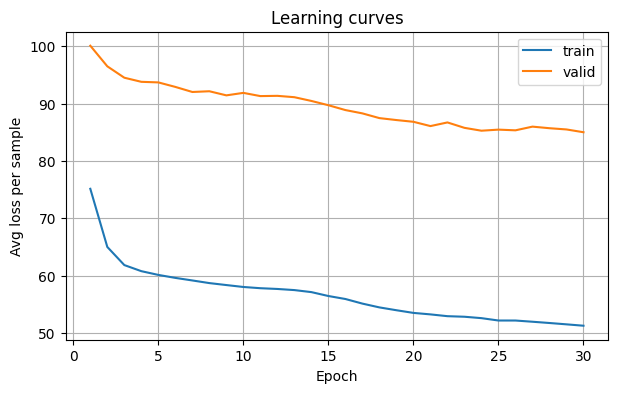

In [212]:
epochs = 30
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MoleculeVAE(vocab_size=vocab_size, seq_len=seq_len).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        x = batch[0].to(device)  # (B, seq_len, vocab)
        targets = x.argmax(dim=-1)  # (B, seq_len)

        optimizer.zero_grad()
        logits, mean, logvar = model(x)  # (B, seq_len, vocab)

        if batch_idx == 0:
            inp = x[0].detach().cpu().numpy()      # (seq_len, vocab)
            out = logits[0].detach().cpu().numpy() # (seq_len, vocab)
            print("Input:")
            print(decode_one_hot(inp.T, all_chars, pad_char=PAD))
            print("Output:")
            print(decode_one_hot(out.T, all_chars, pad_char=PAD))

        loss = vae_loss(logits, targets, mean, logvar, PAD_IDX)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 100 == 0:
            seen = batch_idx * x.size(0)
            total = len(train_loader.dataset)
            pct = 100.0 * batch_idx / len(train_loader)
            print(f"Train Epoch: {epoch} [{seen}/{total} ({pct:.0f}%)]\tLoss: {loss.item():.6f}")

    return total_loss / len(train_loader.dataset)

def eval_one_epoch(loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            targets = x.argmax(dim=-1)
            logits, mean, logvar = model(x)
            loss = vae_loss(logits, targets, mean, logvar, PAD_IDX)
            total_loss += loss.item()
    return total_loss / len(loader.dataset)

train_losses = []
valid_losses = []

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(epoch)
    val_loss = eval_one_epoch(valid_loader)

    train_losses.append(train_loss)
    valid_losses.append(val_loss)

    print(f"Epoch {epoch}: train={train_loss:.6f}  val={val_loss:.6f}")

plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_losses, label="train")
plt.plot(range(1, epochs+1), valid_losses, label="valid")
plt.xlabel("Epoch")
plt.ylabel("Avg loss per sample")
plt.title("Learning curves")
plt.grid(True)
plt.legend()
plt.show()